In [1]:
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from torchvision.models import mobilenet_v2
import torch.nn as nn

import torch
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torch.optim as optim




device = "cuda" if torch.cuda.is_available() else "cpu"
print("✅ Device set to:", device)




✅ Device set to: cuda


In [2]:
import numpy as np

train_seq_paths  = np.load("train_seq_paths.npy", allow_pickle=True)
train_seq_feats  = np.load("train_seq_feats.npy")
train_seq_labels = np.load("train_seq_labels.npy")

val_seq_paths  = np.load("val_seq_paths.npy", allow_pickle=True)
val_seq_feats  = np.load("val_seq_feats.npy")
val_seq_labels = np.load("val_seq_labels.npy")

test_seq_paths  = np.load("test_seq_paths.npy", allow_pickle=True)
test_seq_feats  = np.load("test_seq_feats.npy")
test_seq_labels = np.load("test_seq_labels.npy")

print("✅ Sequences loaded successfully!")


✅ Sequences loaded successfully!


Basline 


In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import json
import os

# ===============================
# 1. Settings
# ===============================
MODEL_NAME = "bilstm_geometric_final"

print("📁 Current working directory:", os.getcwd())
print(f"💾 Model will be saved as: {MODEL_NAME}.pth")
print(f"💾 Results will be saved as: results_{MODEL_NAME}.json")

# ===============================
# 2. Dataset (Geometric Features Only)
# ===============================
class GeometricDataset(Dataset):
    def __init__(self, seq_feats, seq_labels):
        self.seq_feats = seq_feats
        self.seq_labels = seq_labels
        
    def __len__(self):
        return len(self.seq_feats)
    
    def __getitem__(self, idx):
        feats = torch.tensor(self.seq_feats[idx], dtype=torch.float32)
        label = torch.tensor(self.seq_labels[idx], dtype=torch.long)
        return feats, label

# ===============================
# 3. BiLSTM Model
# ===============================
class BiLSTM_Geometric(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=64, num_classes=3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_dim,
            hidden_dim,
            batch_first=True,
            bidirectional=True,
            dropout=0.3
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(hidden_dim * 2, num_classes)
        )
    
    def forward(self, x):
        output, _ = self.lstm(x)
        x = output.mean(dim=1)
        return self.classifier(x)

# ===============================
# 4. Device
# ===============================
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🖥️ Using device: {device}")

# ===============================
# 5. Data Loaders
# ===============================
train_seq_feats = np.array(train_seq_feats, dtype=np.float32)
val_seq_feats   = np.array(val_seq_feats, dtype=np.float32)
test_seq_feats  = np.array(test_seq_feats, dtype=np.float32)

train_ds = GeometricDataset(train_seq_feats, train_seq_labels)
val_ds   = GeometricDataset(val_seq_feats, val_seq_labels)
test_ds  = GeometricDataset(test_seq_feats, test_seq_labels)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=32, shuffle=False)

# ===============================
# 6. Training
# ===============================
net = BiLSTM_Geometric().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=1e-3)
scaler = torch.cuda.amp.GradScaler()

EPOCHS = 30

for epoch in range(1, EPOCHS + 1):
    net.train()
    correct, total = 0, 0
    
    for feats, labels in train_loader:
        feats, labels = feats.to(device), labels.to(device)
        optimizer.zero_grad()
        
        with torch.cuda.amp.autocast():
            outputs = net(feats)
            loss = criterion(outputs, labels)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        correct += (outputs.argmax(1) == labels).sum().item()
        total += feats.size(0)
    
    # Validation
    net.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for feats, labels in val_loader:
            feats, labels = feats.to(device), labels.to(device)
            outputs = net(feats)
            val_correct += (outputs.argmax(1) == labels).sum().item()
            val_total += feats.size(0)
    
    print(f"Epoch {epoch:02d}: Train Acc={correct/total:.4f} | Val Acc={val_correct/val_total:.4f}")

# ===============================
# 7. Final Test
# ===============================
net.eval()
test_preds, test_labels_list = [], []

with torch.no_grad():
    for feats, labels in test_loader:
        feats = feats.to(device)
        labels = labels.to(device)
        outputs = net(feats)
        test_preds.extend(outputs.argmax(1).cpu().numpy())
        test_labels_list.extend(labels.cpu().numpy())

# ===============================
# 8. Metrics
# ===============================
cm = confusion_matrix(test_labels_list, test_preds)
accuracy = cm.trace() / cm.sum()
macro_f1 = f1_score(test_labels_list, test_preds, average="macro")
weighted_f1 = f1_score(test_labels_list, test_preds, average="weighted")

print("\n📊 Final Test Results:")
print(f"Accuracy:    {accuracy:.4f}")
print(f"Macro F1:    {macro_f1:.4f}")
print(f"Weighted F1: {weighted_f1:.4f}")

# ===============================
# 9. Save Model
# ===============================
torch.save(net.state_dict(), f"{MODEL_NAME}.pth")
print(f"\n💾 Model saved to: {MODEL_NAME}.pth")
print("✅ Model file exists:", os.path.exists(f"{MODEL_NAME}.pth"))

# ===============================
# 10. Save Results to JSON
# ===============================
results = {
    "model_name": "BiLSTM_Geometric",
    "accuracy": float(accuracy),
    "macro_f1": float(macro_f1),
    "weighted_f1": float(weighted_f1),
    "confusion_matrix": cm.tolist(),
    "classification_report": classification_report(
        test_labels_list,
        test_preds,
        target_names=["alert", "microsleep", "yawning"],
        output_dict=True
    )
}

with open(f"results_{MODEL_NAME}.json", "w") as f:
    json.dump(results, f, indent=4)

print(f"📄 Results saved to: results_{MODEL_NAME}.json")


📁 Current working directory: /home/jovyan/final 
💾 Model will be saved as: bilstm_geometric_final.pth
💾 Results will be saved as: results_bilstm_geometric_final.json
🖥️ Using device: cuda


/opt/conda/lib/python3.11/site-packages/torch/nn/modules/rnn.py:83: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn("dropout option adds dropout after all but last "


Epoch 01: Train Acc=0.7041 | Val Acc=0.7750
Epoch 02: Train Acc=0.7266 | Val Acc=0.8034
Epoch 03: Train Acc=0.8050 | Val Acc=0.8516
Epoch 04: Train Acc=0.8180 | Val Acc=0.8809
Epoch 05: Train Acc=0.8306 | Val Acc=0.8677
Epoch 06: Train Acc=0.8329 | Val Acc=0.8790
Epoch 07: Train Acc=0.8462 | Val Acc=0.8800
Epoch 08: Train Acc=0.8446 | Val Acc=0.8781
Epoch 09: Train Acc=0.8453 | Val Acc=0.7817
Epoch 10: Train Acc=0.8435 | Val Acc=0.8393
Epoch 11: Train Acc=0.8499 | Val Acc=0.8771
Epoch 12: Train Acc=0.8446 | Val Acc=0.8960
Epoch 13: Train Acc=0.8464 | Val Acc=0.8355
Epoch 14: Train Acc=0.8428 | Val Acc=0.8686
Epoch 15: Train Acc=0.8512 | Val Acc=0.8894
Epoch 16: Train Acc=0.8478 | Val Acc=0.8819
Epoch 17: Train Acc=0.8531 | Val Acc=0.8573
Epoch 18: Train Acc=0.8567 | Val Acc=0.8904
Epoch 19: Train Acc=0.8590 | Val Acc=0.8913
Epoch 20: Train Acc=0.8574 | Val Acc=0.8922
Epoch 21: Train Acc=0.8547 | Val Acc=0.8970
Epoch 22: Train Acc=0.8602 | Val Acc=0.8885
Epoch 23: Train Acc=0.8565 | Val

In [9]:
!pip install jupyter-archive

In [6]:
import zipfile

with zipfile.ZipFile("final.zip","w",zipfile.ZIP_DEFLATED) as z:
    import os
    for root, dirs, files in os.walk("final"):
        for f in files:
            z.write(os.path.join(root, f))

In [11]:
import shutil
import os

# إنشاء ملف zip
shutil.make_archive('final', 'zip', 'final')
print("تم إنشاء final.zip بنجاح")

تم إنشاء final.zip بنجاح


In [13]:
from IPython.display import FileLink, display
import shutil

# إنشاء الملف أولاً
shutil.make_archive('final', 'zip', 'final')

# عرض رابط التحميل
display(FileLink('final.zip'))

/home/jovyan/final /final.zip

In [14]:
import base64
import shutil
from IPython.display import HTML

# إنشاء الملف
shutil.make_archive('final', 'zip', 'final')

# قراءة الملف وعرض رابط التحميل
with open('final.zip', 'rb') as f:
    data = f.read()
    b64 = base64.b64encode(data).decode()
    html = f'''
    <a href="data:application/zip;base64,{b64}" download="final.zip">
        اضغط هنا لتحميل final.zip
    </a>
    '''
    display(HTML(html))

In [10]:
!zip -r final.zip final/

/bin/bash: line 1: zip: command not found


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import json
import os

# ===============================
# 1. تأكيد مكان الحفظ
# ===============================
print("📁 Current working directory:", os.getcwd())
print("💾 Results will be saved as: results_bilstm_geometric_final.json")

# ===============================
# 2. Dataset (للمعالم الهندسية فقط)
# ===============================
class GeometricDataset(Dataset):
    def __init__(self, seq_feats, seq_labels):
        self.seq_feats = seq_feats
        self.seq_labels = seq_labels
        
    def __len__(self):
        return len(self.seq_feats)
    
    def __getitem__(self, idx):
        feats = torch.tensor(self.seq_feats[idx], dtype=torch.float32)
        label = torch.tensor(self.seq_labels[idx], dtype=torch.long)
        return feats, label

# ===============================
# 3. نموذج BiLSTM
# ===============================
class BiLSTM_Geometric(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=64, num_classes=3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_dim, 
            hidden_dim, 
            batch_first=True, 
            bidirectional=True,
            dropout=0.3
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(hidden_dim * 2, num_classes)
        )
    
    def forward(self, x):
        output, _ = self.lstm(x)
        x = output.mean(dim=1)  
        return self.classifier(x)

# ===============================
# 4. DEVICE
# ===============================
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🖥️ Using device: {device}")

# ===============================
# 5. Data Loaders (تأكد أن train_seq_feats موجودة)
# ===============================
train_seq_feats = np.array(train_seq_feats, dtype=np.float32)
val_seq_feats = np.array(val_seq_feats, dtype=np.float32)
test_seq_feats = np.array(test_seq_feats, dtype=np.float32)

train_ds = GeometricDataset(train_seq_feats, train_seq_labels)
val_ds = GeometricDataset(val_seq_feats, val_seq_labels)
test_ds = GeometricDataset(test_seq_feats, test_seq_labels)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

# ===============================
# 6. Training
# ===============================
model = BiLSTM_Geometric().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scaler = torch.cuda.amp.GradScaler()

EPOCHS = 30

for epoch in range(1, EPOCHS + 1):
    model.train()
    correct, total = 0, 0
    
    for feats, labels in train_loader:
        feats, labels = feats.to(device), labels.to(device)
        optimizer.zero_grad()
        
        with torch.cuda.amp.autocast():
            outputs = model(feats)
            loss = criterion(outputs, labels)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        correct += (outputs.argmax(1) == labels).sum().item()
        total += feats.size(0)
    
    # Validation
    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for feats, labels in val_loader:
            feats, labels = feats.to(device), labels.to(device)
            outputs = model(feats)
            val_correct += (outputs.argmax(1) == labels).sum().item()
            val_total += feats.size(0)
    
    print(f"Epoch {epoch:2d}: Train Acc={correct/total:.4f} | Val Acc={val_correct/val_total:.4f}")

# ===============================
# 7. Final Test
# ===============================
model.eval()
test_preds, test_labels_list = [], []

with torch.no_grad():
    for feats, labels in test_loader:
        feats = feats.to(device)
        labels = labels.to(device)
        outputs = model(feats)
        test_preds.extend(outputs.argmax(1).cpu().numpy())
        test_labels_list.extend(labels.cpu().numpy())

# ===============================
# 8. Metrics Calculation
# ===============================
cm = confusion_matrix(test_labels_list, test_preds)
accuracy = cm.trace() / cm.sum()
macro_f1 = f1_score(test_labels_list, test_preds, average='macro')
weighted_f1 = f1_score(test_labels_list, test_preds, average='weighted')

print("\n📊 Final Test Results:")
print(f"Accuracy:    {accuracy:.4f}")
print(f"Macro F1:    {macro_f1:.4f}")
print(f"Weighted F1: {weighted_f1:.4f}")

# Classification Report
report = classification_report(
    test_labels_list, test_preds,
    target_names=['alert', 'microsleep', 'yawning']
)
print("\n📋 Classification Report:")
print(report)

# ===============================
# 9. Save FULL Results to JSON
# ===============================
results = {
    "model_name": "BiLSTM_Geometric_Final",
    "accuracy": float(accuracy),
    "macro_f1": float(macro_f1),
    "weighted_f1": float(weighted_f1),
    "confusion_matrix": cm.tolist(),
    "classification_report": classification_report(
        test_labels_list, test_preds,
        target_names=['alert', 'microsleep', 'yawning'],
        output_dict=True
    )
}

json_path = "results_bilstm_geometric_final.json"
with open(json_path, "w") as f:
    json.dump(results, f, indent=4)

print(f"\n✅ Results saved to: {json_path}")

📁 Current working directory: /home/jovyan/final 
💾 Results will be saved as: results_bilstm_geometric_final.json
🖥️ Using device: cuda


/opt/conda/lib/python3.11/site-packages/torch/nn/modules/rnn.py:83: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn("dropout option adds dropout after all but last "


Epoch  1: Train Acc=0.6961 | Val Acc=0.7637
Epoch  2: Train Acc=0.7609 | Val Acc=0.8450
Epoch  3: Train Acc=0.8137 | Val Acc=0.8620
Epoch  4: Train Acc=0.8210 | Val Acc=0.8393
Epoch  5: Train Acc=0.8228 | Val Acc=0.8696
Epoch  6: Train Acc=0.8370 | Val Acc=0.8667
Epoch  7: Train Acc=0.8435 | Val Acc=0.8582
Epoch  8: Train Acc=0.8405 | Val Acc=0.8488
Epoch  9: Train Acc=0.8476 | Val Acc=0.8705
Epoch 10: Train Acc=0.8432 | Val Acc=0.8743
Epoch 11: Train Acc=0.8425 | Val Acc=0.8743
Epoch 12: Train Acc=0.8402 | Val Acc=0.8781
Epoch 13: Train Acc=0.8494 | Val Acc=0.8828
Epoch 14: Train Acc=0.8494 | Val Acc=0.8733
Epoch 15: Train Acc=0.8506 | Val Acc=0.8856
Epoch 16: Train Acc=0.8448 | Val Acc=0.8847
Epoch 17: Train Acc=0.8526 | Val Acc=0.8809
Epoch 18: Train Acc=0.8567 | Val Acc=0.8611
Epoch 19: Train Acc=0.8526 | Val Acc=0.8885
Epoch 20: Train Acc=0.8584 | Val Acc=0.8639
Epoch 21: Train Acc=0.8593 | Val Acc=0.8998
Epoch 22: Train Acc=0.8506 | Val Acc=0.8894
Epoch 23: Train Acc=0.8517 | Val

BiLSTM **(Geometric Features Only)

3D-CNN

In [47]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np

# ===============================
# 1. Dataset (مخصص لـ 3D-CNN)
# ===============================
class Video3D_Dataset(Dataset):
    def __init__(self, seq_paths, seq_labels, transform):
        self.seq_paths = seq_paths
        self.seq_labels = seq_labels
        self.tf = transform
        
    def __len__(self):
        return len(self.seq_paths)
    
    def __getitem__(self, idx):
        paths = self.seq_paths[idx]
        label = self.seq_labels[idx]
        
        # تحميل الإطارات وتحويلها إلى (T, C, H, W)
        frames = torch.stack([self.tf(Image.open(p).convert("RGB")) for p in paths])
        label = torch.tensor(label, dtype=torch.long)
        
        return frames, label  # (T, C, H, W)

# ===============================
# 2. نموذج 3D-CNN مبسط (بدون pretrained weights لتجنب OOM)
# ===============================
class Simple3DCNN(nn.Module):
    def __init__(self, num_classes=3, seq_length=32):
        super().__init__()
        self.features = nn.Sequential(
            # (C, T, H, W) → (64, T-2, H/2, W/2)
            nn.Conv3d(3, 64, kernel_size=(3, 3, 3), padding=(1, 1, 1)),
            nn.ReLU(),
            nn.MaxPool3d(kernel_size=(1, 2, 2)),
            
            # (64, T-2, H/2, W/2) → (128, T-4, H/4, W/4)
            nn.Conv3d(64, 128, kernel_size=(3, 3, 3), padding=(1, 1, 1)),
            nn.ReLU(),
            nn.MaxPool3d(kernel_size=(2, 2, 2)),
            
            # (128, T-4, H/4, W/4) → (256, T-6, H/8, W/8)
            nn.Conv3d(128, 256, kernel_size=(3, 3, 3), padding=(1, 1, 1)),
            nn.ReLU(),
            nn.AdaptiveAvgPool3d((8, 4, 4))  # تثبيت الحجم النهائي
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256 * 8 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
    
    def forward(self, x):
        # x: (B, T, C, H, W) → (B, C, T, H, W)
        x = x.permute(0, 2, 1, 3, 4)
        x = self.features(x)  # (B, 256, 8, 4, 4)
        x = x.view(x.size(0), -1)  # (B, 256*8*4*4)
        return self.classifier(x)

# ===============================
# 3. الإعدادات
# ===============================
device = "cuda" if torch.cuda.is_available() else "cpu"

# Transform (يجب أن يكون نفس الحجم لكل الإطارات)
img_tf = transforms.Compose([
    transforms.Resize((112, 112)),  # 3D-CNN يستخدم عادةً 112x112
    transforms.ToTensor()
])

# ===============================
# 4. بناء DataLoaders
# ===============================
train_ds = Video3D_Dataset(train_seq_paths, train_seq_labels, img_tf)
val_ds = Video3D_Dataset(val_seq_paths, val_seq_labels, img_tf)
test_ds = Video3D_Dataset(test_seq_paths, test_seq_labels, img_tf)

# Batch Size أصغر بسبب استهلاك الذاكرة العالي
train_loader = DataLoader(train_ds, batch_size=2, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=2, shuffle=False, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=2, shuffle=False, num_workers=2)

# ===============================
# 5. التدريب
# ===============================
model = Simple3DCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scaler = torch.cuda.amp.GradScaler()

EPOCHS = 15

for epoch in range(1, EPOCHS + 1):
    model.train()
    correct, total, train_loss = 0, 0, 0
    
    for frames, labels in train_loader:
        frames, labels = frames.to(device), labels.to(device)
        optimizer.zero_grad()
        
        with torch.cuda.amp.autocast():
            outputs = model(frames)
            loss = criterion(outputs, labels)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        train_loss += loss.item() * frames.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += frames.size(0)
    
    # التحقق
    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for frames, labels in val_loader:
            frames, labels = frames.to(device), labels.to(device)
            outputs = model(frames)
            val_correct += (outputs.argmax(1) == labels).sum().item()
            val_total += frames.size(0)
    
    train_acc = correct / total
    val_acc = val_correct / val_total
    print(f"Epoch {epoch}: Train Acc={train_acc:.4f} | Val Acc={val_acc:.4f}")

# ===============================
# 🔥 حفظ المودل بعد التدريب
# ===============================
torch.save(model.state_dict(), "best_3dcnn.pth")
print("✅ 3D-CNN model saved as best_3dcnn.pth")

# ===============================
# 6. التقييم النهائي
# ===============================
model.eval()
test_preds, test_labels = [], []

with torch.no_grad():
    for frames, labels in test_loader:
        frames, labels = frames.to(device), labels.to(device)
        outputs = model(frames)
        test_preds.extend(outputs.argmax(1).cpu().numpy())
        test_labels.extend(labels.cpu().numpy())

from sklearn.metrics import classification_report
print("\n📊 3D-CNN Baseline Results:")
print(classification_report(test_labels, test_preds,
                          target_names=['alert', 'microsleep', 'yawning']))


Epoch 1: Train Acc=0.7341 | Val Acc=0.8554
Epoch 2: Train Acc=0.8581 | Val Acc=0.8318
Epoch 3: Train Acc=0.8895 | Val Acc=0.8573
Epoch 4: Train Acc=0.9143 | Val Acc=0.8705
Epoch 5: Train Acc=0.9289 | Val Acc=0.8620
Epoch 6: Train Acc=0.9335 | Val Acc=0.8856
Epoch 7: Train Acc=0.9432 | Val Acc=0.9159
Epoch 8: Train Acc=0.9493 | Val Acc=0.9329
Epoch 9: Train Acc=0.9567 | Val Acc=0.9206
Epoch 10: Train Acc=0.9581 | Val Acc=0.9480
Epoch 11: Train Acc=0.9647 | Val Acc=0.9395
Epoch 12: Train Acc=0.9613 | Val Acc=0.9367
Epoch 13: Train Acc=0.9688 | Val Acc=0.9055
Epoch 14: Train Acc=0.9691 | Val Acc=0.9225
Epoch 15: Train Acc=0.9677 | Val Acc=0.9442
✅ 3D-CNN model saved as best_3dcnn.pth

📊 3D-CNN Baseline Results:
              precision    recall  f1-score   support

       alert       0.99      0.95      0.97       844
  microsleep       0.82      0.93      0.87       163
     yawning       0.96      0.99      0.97        87

    accuracy                           0.95      1094
   macro a

In [9]:
model = Simple3DCNN(num_classes=3).to(device)


In [10]:
import torch

model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

print("✅ تم تحميل مودل 3D-CNN بنجاح")


✅ تم تحميل مودل 3D-CNN بنجاح


✓ Test predictions collected

Confusion Matrix:
 [[806  34   4]
 [ 11 152   0]
 [  1   0  86]]


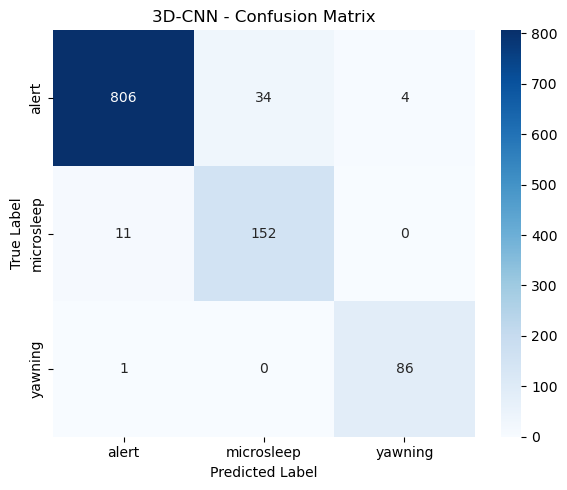

⚠️ ملف JSON غير موجود… سيتم إنشاء واحد جديد.
✓ Confusion Matrix saved to: results_3dcnn.json


In [11]:
import torch
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import json

# ==========================
# 1) استخراج التوقعات من 3D-CNN
# ==========================
model.eval()
test_preds, test_labels = [], []

with torch.no_grad():
    for frames, labels in test_loader:
        frames = frames.to(device)
        labels = labels.to(device)

        outputs = model(frames)
        preds = outputs.argmax(1)

        test_preds.extend(preds.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())

print("✓ Test predictions collected")

# ==========================
# 2) حساب Confusion Matrix
# ==========================
cm = confusion_matrix(test_labels, test_preds)
print("\nConfusion Matrix:\n", cm)

# ==========================
# 3) رسم Confusion Matrix
# ==========================
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            cmap="Blues",
            xticklabels=['alert', 'microsleep', 'yawning'],
            yticklabels=['alert', 'microsleep', 'yawning'])
plt.title("3D-CNN - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# ==========================
# 4) حفظ Confusion Matrix داخل JSON
# ==========================
json_path = "results_3dcnn.json"

try:
    with open(json_path, "r") as f:
        data = json.load(f)
except:
    print("⚠️ ملف JSON غير موجود… سيتم إنشاء واحد جديد.")
    data = {}

data["confusion_matrix"] = cm.tolist()

with open(json_path, "w") as f:
    json.dump(data, f, indent=4)

print(f"✓ Confusion Matrix saved to: {json_path}")


In [48]:
import os
os.makedirs("saved_models", exist_ok=True)

# حفظ النموذج كاملاً (Architecture + Weights)
torch.save(model, "3dcnn_full_model.pth")


In [49]:
# ===============================
# 7. حفظ نتائج التقييم في JSON للمقارنة
# ===============================
import json

results = classification_report(
    test_labels, test_preds,
    target_names=['alert', 'microsleep', 'yawning'],
    output_dict=True
)

summary = {
    "model_name": "Simple3DCNN_Baseline",
    "accuracy": float(results["accuracy"]),
    "macro_f1": float(results["macro avg"]["f1-score"]),
    "weighted_f1": float(results["weighted avg"]["f1-score"]),
    
    "class_f1": {
        "alert": float(results["alert"]["f1-score"]),
        "microsleep": float(results["microsleep"]["f1-score"]),
        "yawning": float(results["yawning"]["f1-score"])
    }
}

with open("results_3dcnn.json", "w") as f:
    json.dump(summary, f, indent=4)

print("📁 تم حفظ نتائج 3D-CNN → results_3dcnn.json")


📁 تم حفظ نتائج 3D-CNN → results_3dcnn.json


CNN + LSTM 

In [31]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np

# ============================================================
# 1) Dataset بسيط
# ============================================================
class SeqDataset(Dataset):
    def __init__(self, seq_paths, seq_labels, transform):
        self.paths = seq_paths
        self.labels = seq_labels
        self.tf = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        imgs = [self.tf(Image.open(p).convert("RGB")) for p in self.paths[idx]]
        imgs = torch.stack(imgs)   # (T, C, H, W)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return imgs, label


# ============================================================
# 2) CNN + LSTM Model
# ============================================================
class CNN_LSTM(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()

        # CNN Feature extractor
        self.cnn = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),                              # 160 → 80

            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),                              # 80 → 40

            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4))                  # output: (256,4,4)
        )

        # LSTM
        self.lstm = nn.LSTM(
            input_size=256 * 4 * 4,
            hidden_size=128,
            batch_first=True,
            dropout=0.3
        )

        # Final classifier
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # x = (B, T, C, H, W)
        B, T, C, H, W = x.shape

        # Apply CNN frame by frame
        x = x.view(B*T, C, H, W)
        x = self.cnn(x)

        # flatten
        x = x.view(B, T, -1)

        # LSTM
        _, (h, _) = self.lstm(x)
        h_last = h.squeeze(0)

        # Classifier
        return self.classifier(h_last)


# ============================================================
# 3) Transform
# ============================================================
img_tf = transforms.Compose([
    transforms.Resize((160, 160)),
    transforms.ToTensor()
])


# ============================================================
# 4) Data Loaders
# ============================================================
train_ds = SeqDataset(train_seq_paths, train_seq_labels, img_tf)
val_ds   = SeqDataset(val_seq_paths,  val_seq_labels,  img_tf)
test_ds  = SeqDataset(test_seq_paths, test_seq_labels, img_tf)

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=4, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=4, shuffle=False, num_workers=2)

print("✓ DataLoaders Ready!")


# ============================================================
# 5) Training Setup
# ============================================================
device = "cuda" if torch.cuda.is_available() else "cpu"

model = CNN_LSTM().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scaler = torch.cuda.amp.GradScaler()

EPOCHS = 20


# ============================================================
# 6) Training Loop
# ============================================================
for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            out = model(imgs)
            loss = criterion(out, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * imgs.size(0)
        correct += (out.argmax(1) == labels).sum().item()
        total += imgs.size(0)

    acc = correct / total
    print(f"Epoch {epoch}/{EPOCHS} | Loss={total_loss/total:.4f} | Acc={acc:.4f}")


# ============================================================
# 7) Save Model
# ============================================================
torch.save(model.state_dict(), "best_cnn_lstm_model.pth")
print("\n✓ Model saved as best_cnn_lstm_model.pth")


# ============================================================
# 8) Test Evaluation
# ============================================================
model.eval()
preds, trues = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        out = model(imgs)
        preds.extend(out.argmax(1).cpu().numpy())
        trues.extend(labels.numpy())

from sklearn.metrics import classification_report

print("\n📊 CNN+LSTM Test Results:")
print(classification_report(trues, preds, 
       target_names=['alert', 'microsleep', 'yawning']))

✓ DataLoaders Ready!
Epoch 1/20 | Loss=0.7591 | Acc=0.7052
Epoch 2/20 | Loss=0.5970 | Acc=0.7424
Epoch 3/20 | Loss=0.5208 | Acc=0.7807
Epoch 4/20 | Loss=0.4527 | Acc=0.8205
Epoch 5/20 | Loss=0.4523 | Acc=0.8189
Epoch 6/20 | Loss=0.3693 | Acc=0.8547
Epoch 7/20 | Loss=0.3562 | Acc=0.8524
Epoch 8/20 | Loss=0.3053 | Acc=0.8758
Epoch 9/20 | Loss=0.2798 | Acc=0.8902
Epoch 10/20 | Loss=0.2804 | Acc=0.8923
Epoch 11/20 | Loss=0.2450 | Acc=0.9069
Epoch 12/20 | Loss=0.2155 | Acc=0.9108
Epoch 13/20 | Loss=0.2117 | Acc=0.9205
Epoch 14/20 | Loss=0.1819 | Acc=0.9292
Epoch 15/20 | Loss=0.1908 | Acc=0.9287
Epoch 16/20 | Loss=0.1509 | Acc=0.9436
Epoch 17/20 | Loss=0.1465 | Acc=0.9448
Epoch 18/20 | Loss=0.1552 | Acc=0.9438
Epoch 19/20 | Loss=0.1335 | Acc=0.9516
Epoch 20/20 | Loss=0.1285 | Acc=0.9487

✓ Model saved as best_cnn_lstm_model.pth

📊 CNN+LSTM Test Results:
              precision    recall  f1-score   support

       alert       0.99      0.86      0.92       844
  microsleep       0.58      0.

In [4]:
import torch
import torch.nn as nn

class CNN_LSTM(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4))
        )

        self.lstm = nn.LSTM(
            input_size=256 * 4 * 4,
            hidden_size=128,
            batch_first=True,
            dropout=0.3
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        B, T, C, H, W = x.shape
        x = x.view(B*T, C, H, W)
        x = self.cnn(x)
        x = x.view(B, T, -1)
        _, (h, _) = self.lstm(x)
        h_last = h.squeeze(0)
        return self.classifier(h_last)


In [6]:
import torch
import torch.nn as nn
import os

device = "cuda" if torch.cuda.is_available() else "cpu"

MODEL_PATH = "./experiments/best_cnn_lstm_model.pth"

# تأكيد وجود الملف
assert os.path.exists(MODEL_PATH), f"❌ File not found: {MODEL_PATH}"

# إنشاء النموذج
model = CNN_LSTM().to(device)

# تحميل الأوزان (لأنك حفظتِ state_dict فقط)
model.load_state_dict(
    torch.load(MODEL_PATH, map_location=device)
)

model.eval()

print("✅ CNN+LSTM model loaded successfully")


✅ CNN+LSTM model loaded successfully


In [26]:
import os
import gc
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np

# ===============================
# 0. إعداد الذاكرة
# ===============================
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
gc.collect()
torch.cuda.empty_cache()

# ===============================
# 1. Dataset (لإطار واحد)
# ===============================
class SingleFrameDataset(Dataset):
    def __init__(self, image_paths, labels, transform):
        self.image_paths = image_paths
        self.labels = labels
        self.tf = transform
        
    def __len__(self):
        return len(self.image_paths)
    
    def load_img(self, p):
        img = Image.open(p).convert("RGB")
        # ↓↓ تقليل حجم الصورة قبل التحويل (مهم جدًا لتقليل الذاكرة)
        img = img.resize((160, 160))
        return self.tf(img)
    
    def __getitem__(self, idx):
        path = self.image_paths[idx]
        label = self.labels[idx]
        img = self.load_img(path)
        label = torch.tensor(label, dtype=torch.long)
        return img, label

# ===============================
# 2. نموذج CNN بسيط
# ===============================
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # ↓↓ تخفيف عدد الفلاتر
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4))
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

# ===============================
# 3. الإعدادات
# ===============================
device = "cuda" if torch.cuda.is_available() else "cpu"
img_tf = transforms.Compose([transforms.ToTensor()])

# ===============================
# 4. بناء DataLoaders
# ===============================
def flatten_sequences(seq_paths, seq_labels):
    flat_paths = []
    flat_labels = []
    for paths, label in zip(seq_paths, seq_labels):
        flat_paths.extend(paths)
        flat_labels.extend([label] * len(paths))
    return flat_paths, flat_labels

train_flat_paths, train_flat_labels = flatten_sequences(train_seq_paths, train_seq_labels)
val_flat_paths, val_flat_labels = flatten_sequences(val_seq_paths, val_seq_labels)
test_flat_paths, test_flat_labels = flatten_sequences(test_seq_paths, test_seq_labels)

# ↓↓ تقليل batch size لتقليل الذاكرة
train_loader = DataLoader(SingleFrameDataset(train_flat_paths, train_flat_labels, img_tf),
                          batch_size=8, shuffle=True, num_workers=2)
val_loader = DataLoader(SingleFrameDataset(val_flat_paths, val_flat_labels, img_tf),
                        batch_size=8, shuffle=False, num_workers=2)
test_loader = DataLoader(SingleFrameDataset(test_flat_paths, test_flat_labels, img_tf),
                         batch_size=8, shuffle=False, num_workers=2)

# ===============================
# 5. التدريب
# ===============================
model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scaler = torch.cuda.amp.GradScaler()

EPOCHS = 20

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        
        with torch.cuda.amp.autocast():
            outputs = model(imgs)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * imgs.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += imgs.size(0)

        # ↓↓ تنظيف الذاكرة بعد كل batch
        del imgs, labels, outputs, loss
        torch.cuda.empty_cache()

    train_acc = correct / total
    print(f"Epoch {epoch}/{EPOCHS} | Train Loss: {total_loss/total:.4f} | Train Acc: {train_acc:.4f}")


# ===============================
# 6. التقييم على الاختبار
# ===============================
model.eval()
test_preds = []
test_labels = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        
        with torch.cuda.amp.autocast():
            outputs = model(imgs)

        test_preds.extend(outputs.argmax(1).cpu().numpy())
        test_labels.extend(labels.cpu().numpy())

from sklearn.metrics import classification_report
print("\n📊 CNN (Single Frame) Results:")
print(classification_report(test_labels, test_preds,
      target_names=['alert', 'microsleep', 'yawning']))


Epoch 1/20 | Train Loss: 0.3888 | Train Acc: 0.8534
Epoch 2/20 | Train Loss: 0.2988 | Train Acc: 0.8915
Epoch 3/20 | Train Loss: 0.2835 | Train Acc: 0.8977
Epoch 4/20 | Train Loss: 0.2749 | Train Acc: 0.9001
Epoch 5/20 | Train Loss: 0.2693 | Train Acc: 0.9017
Epoch 6/20 | Train Loss: 0.2662 | Train Acc: 0.9024
Epoch 7/20 | Train Loss: 0.2633 | Train Acc: 0.9027
Epoch 8/20 | Train Loss: 0.2631 | Train Acc: 0.9026
Epoch 9/20 | Train Loss: 0.2623 | Train Acc: 0.9035
Epoch 10/20 | Train Loss: 0.2609 | Train Acc: 0.9030
Epoch 11/20 | Train Loss: 0.2602 | Train Acc: 0.9032
Epoch 12/20 | Train Loss: 0.2599 | Train Acc: 0.9028
Epoch 13/20 | Train Loss: 0.2598 | Train Acc: 0.9027
Epoch 14/20 | Train Loss: 0.2599 | Train Acc: 0.9035
Epoch 15/20 | Train Loss: 0.2586 | Train Acc: 0.9033
Epoch 16/20 | Train Loss: 0.2598 | Train Acc: 0.9039
Epoch 17/20 | Train Loss: 0.2589 | Train Acc: 0.9039
Epoch 18/20 | Train Loss: 0.2585 | Train Acc: 0.9039
Epoch 19/20 | Train Loss: 0.2588 | Train Acc: 0.9030
Ep

In [13]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4))
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


In [14]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = SimpleCNN(num_classes=3).to(device)
print("✅ Model architecture created")


✅ Model architecture created


In [17]:
import torch

MODEL_PATH = "experiments/simple_cnn_full.pth"

model = torch.load(MODEL_PATH, map_location=device)
model.eval()

print("✅ CNN model loaded successfully (full model)")
print(type(model))


✅ CNN model loaded successfully (full model)
<class '__main__.SimpleCNN'>


In [18]:
torch.save(model.state_dict(), "simple_cnn_state_dict.pth")


In [19]:
model = SimpleCNN(num_classes=3).to(device)
model.load_state_dict(torch.load("simple_cnn_state_dict.pth", map_location=device))
model.eval()


SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): AdaptiveAvgPool2d(output_size=(4, 4))
  )
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=3, bias=True)
  )
)

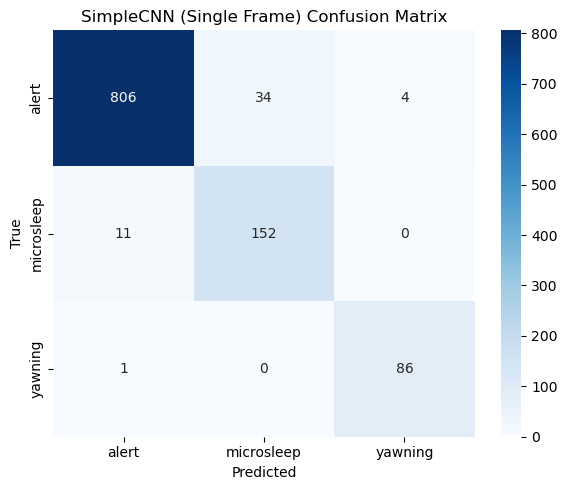

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=['alert', 'microsleep', 'yawning'],
    yticklabels=['alert', 'microsleep', 'yawning']
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("SimpleCNN (Single Frame) Confusion Matrix")
plt.tight_layout()
plt.show()


In [22]:
import json
results = classification_report(
    test_labels, test_preds,
    target_names=['alert', 'microsleep', 'yawning'],
    output_dict=True
)

summary = {
    "model_name": "SimpleCNN_SingleFrame",
    "accuracy": results["accuracy"],
    "macro_f1": results["macro avg"]["f1-score"],
    "weighted_f1": results["weighted avg"]["f1-score"],
    "alert_f1": results["alert"]["f1-score"],
    "microsleep_f1": results["microsleep"]["f1-score"],
    "yawning_f1": results["yawning"]["f1-score"],
}

with open("results_CNN_single_frame.json", "w") as f:
    json.dump(summary, f, indent=4)

print("📁 Results saved → results_CNN_single_frame.json")


📁 Results saved → results_CNN_single_frame.json


In [29]:
!pip install pycryptodome


  Using cached pycryptodome-3.23.0-cp37-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (3.4 kB)
Using cached pycryptodome-3.23.0-cp37-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (2.3 MB)


In [4]:
import torch
import torch.nn as nn

class BiLSTM_Geometric(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=64, num_classes=3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_dim,
            hidden_dim,
            batch_first=True,
            bidirectional=True
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(hidden_dim * 2, num_classes)
        )

    def forward(self, x):
        output, _ = self.lstm(x)
        x = output.mean(dim=1)
        return self.classifier(x)


In [29]:
device = "cuda" if torch.cuda.is_available() else "cpu"

MODEL_PATH = "./experiments/bilstm_geometric_final.pth"

bilstm_model = BiLSTM_Geometric().to(device)

bilstm_model.load_state_dict(
    torch.load(MODEL_PATH, map_location=device)
)

bilstm_model.eval()

print("✅ BiLSTM Geometric model loaded successfully")
print(f"📁 Loaded from: {MODEL_PATH}")


✅ BiLSTM Geometric model loaded successfully
📁 Loaded from: ./experiments/bilstm_geometric_final.pth


In [19]:
import torch
import torch.nn as nn

class CNN_LSTM(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4))
        )

        self.lstm = nn.LSTM(
            input_size=256 * 4 * 4,
            hidden_size=128,
            batch_first=True
        )

        # ✅ نفس تعريف التدريب
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        B, T, C, H, W = x.shape
        x = x.view(B * T, C, H, W)
        x = self.cnn(x)
        x = x.view(B, T, -1)
        _, (h, _) = self.lstm(x)
        return self.classifier(h.squeeze(0))


In [20]:
import os
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

MODEL_PATH = "./experiments/best_cnn_lstm_model.pth"
assert os.path.exists(MODEL_PATH), f"❌ File not found: {MODEL_PATH}"

cnn_lstm_model = CNN_LSTM().to(device)
cnn_lstm_model.load_state_dict(
    torch.load(MODEL_PATH, map_location=device)
)
cnn_lstm_model.eval()

print("✅ CNN+LSTM model loaded successfully")


✅ CNN+LSTM model loaded successfully


In [21]:
import torch
import torch.nn as nn

class Simple3DCNN(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv3d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool3d((1, 2, 2)),

            nn.Conv3d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool3d((2, 2, 2)),

            nn.Conv3d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool3d((8, 4, 4))
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256 * 8 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = x.permute(0, 2, 1, 3, 4)  # (B, C, T, H, W)
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


In [22]:
device = "cuda" if torch.cuda.is_available() else "cpu"

MODEL_PATH_3DCNN = "./experiments/best_3dcnn.pth"

cnn3d_model = Simple3DCNN().to(device)

cnn3d_model.load_state_dict(
    torch.load(MODEL_PATH_3DCNN, map_location=device)
)

cnn3d_model.eval()

print("✅ 3D-CNN model loaded successfully")


✅ 3D-CNN model loaded successfully


In [31]:
class CNNTransformer(nn.Module):
    def __init__(self, extra_dim=4, num_heads=4, num_classes=3, dropout=0.3):
        super().__init__()

        m = mobilenet_v2(weights="IMAGENET1K_V1")
        self.cnn = m.features
        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.reduce = nn.Sequential(
            nn.Linear(1280, 512),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.d_model = 512 + extra_dim

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.d_model,
            nhead=num_heads,
            dim_feedforward=1024,
            dropout=dropout,
            batch_first=True,
            activation="gelu"
        )

        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=3)

        self.fc = nn.Sequential(
            nn.Linear(self.d_model, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, imgs, feats):
        B, T, C, H, W = imgs.shape
        x = imgs.view(B * T, C, H, W)

        x = self.cnn(x)
        x = self.pool(x).view(B, T, 1280)
        x = self.reduce(x)

        x = torch.cat([x, feats], dim=2)
        x = self.transformer(x)

        x = x.mean(dim=1) + x.max(dim=1)[0]
        return self.fc(x)


In [34]:
checkpoint = torch.load(
    "best_cnn_transformer_encrypted.pth",
    map_location=device
)

encrypted_model = CNNTransformer().to(device)

encrypted_model.load_state_dict(checkpoint["model_state_dict"])
encrypted_model.eval()

print("✅ Encrypted CNN+Transformer model loaded")
print(f"📌 Epoch: {checkpoint['epoch']}")


✅ Encrypted CNN+Transformer model loaded
📌 Epoch: 6


In [41]:
import os
import json
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import mobilenet_v2
from PIL import Image
import numpy as np
from tqdm import tqdm

# ============================================================
# 0) DEVICE
# ============================================================

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# ============================================================
# 1) CNN + TRANSFORMER (ENCRYPTED – FINAL MODEL)
# ============================================================

class CNNTransformer(nn.Module):
    def __init__(self, extra_dim=4, num_heads=4, num_classes=3, dropout=0.3):
        super().__init__()

        backbone = mobilenet_v2(weights="IMAGENET1K_V1")
        self.cnn = backbone.features
        self.pool = nn.AdaptiveAvgPool2d((1,1))

        self.reduce = nn.Sequential(
            nn.Linear(1280, 512),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.d_model = 512 + extra_dim

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.d_model,
            nhead=num_heads,
            dim_feedforward=1024,
            dropout=dropout,
            batch_first=True,
            activation="gelu"
        )

        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=3)

        self.fc = nn.Sequential(
            nn.Linear(self.d_model, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, imgs, feats):
        B, T, C, H, W = imgs.shape
        x = imgs.view(B*T, C, H, W)
        x = self.cnn(x)
        x = self.pool(x)
        x = x.view(B, T, 1280)

        x = self.reduce(x)
        x = torch.cat([x, feats], dim=2)

        x = self.transformer(x)
        x = x.mean(dim=1) + x.max(dim=1)[0]

        return self.fc(x)

# ============================================================
# 2) DATASETS
# ============================================================

class SeqDatasetTransformer(Dataset):
    def __init__(self, paths, feats, labels, tf):
        self.paths = paths
        self.feats = feats
        self.labels = labels
        self.tf = tf

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        imgs = torch.stack([self.tf(Image.open(p).convert("RGB"))
                            for p in self.paths[idx]])
        feats = torch.tensor(self.feats[idx], dtype=torch.float32)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return imgs, feats, label


class SeqDatasetImages(Dataset):
    def __init__(self, paths, labels, tf):
        self.paths = paths
        self.labels = labels
        self.tf = tf

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        imgs = torch.stack([self.tf(Image.open(p).convert("RGB"))
                            for p in self.paths[idx]])
        return imgs, torch.tensor(self.labels[idx], dtype=torch.long)


class Video3D_Dataset(Dataset):
    def __init__(self, paths, labels, tf):
        self.paths = paths
        self.labels = labels
        self.tf = tf

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        frames = torch.stack([self.tf(Image.open(p).convert("RGB"))
                              for p in self.paths[idx]])
        return frames, torch.tensor(self.labels[idx], dtype=torch.long)


class GeometricDataset(Dataset):
    def __init__(self, feats, labels):
        self.feats = feats
        self.labels = labels

    def __len__(self):
        return len(self.feats)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.feats[idx], dtype=torch.float32),
            torch.tensor(self.labels[idx], dtype=torch.long)
        )

# ============================================================
# 3) TRANSFORMS
# ============================================================

tf_transformer = transforms.Compose([
    transforms.Resize((160,160)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

tf_lstm = transforms.Compose([
    transforms.Resize((160,160)),
    transforms.ToTensor()
])

tf_3d = transforms.Compose([
    transforms.Resize((112,112)),
    transforms.ToTensor()
])

# ============================================================
# 4) TEST LOADERS
# ============================================================

test_loader_transformer = DataLoader(
    SeqDatasetTransformer(test_seq_paths, test_seq_feats, test_seq_labels, tf_transformer),
    batch_size=4, shuffle=False
)

test_loader_cnn_lstm = DataLoader(
    SeqDatasetImages(test_seq_paths, test_seq_labels, tf_lstm),
    batch_size=4, shuffle=False
)

test_loader_3d = DataLoader(
    Video3D_Dataset(test_seq_paths, test_seq_labels, tf_3d),
    batch_size=2, shuffle=False
)

test_loader_geom = DataLoader(
    GeometricDataset(test_seq_feats, test_seq_labels),
    batch_size=32, shuffle=False
)

print("✓ Test loaders ready")

# ============================================================
# 5) LOAD MODELS
# ============================================================

print("\nLoading models...")

# --- Encrypted Transformer ---
ckpt = torch.load("best_cnn_transformer_encrypted.pth", map_location=device)
model_transformer = CNNTransformer().to(device)
model_transformer.load_state_dict(ckpt["model_state_dict"])
model_transformer.eval()
print("✓ Encrypted Transformer loaded")

# --- CNN + LSTM ---
class CNN_LSTM(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(3,64,3,padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(128,256,3,padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d((4,4))
        )
        self.lstm = nn.LSTM(256*4*4, 128, batch_first=True, dropout=0.3)
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        B,T,C,H,W = x.shape
        x = x.view(B*T,C,H,W)
        x = self.cnn(x)
        x = x.view(B,T,-1)
        _,(h,_) = self.lstm(x)
        return self.classifier(h.squeeze(0))

model_cnn_lstm = CNN_LSTM().to(device)
model_cnn_lstm.load_state_dict(
    torch.load("experiments/best_cnn_lstm_model.pth", map_location=device)
)
model_cnn_lstm.eval()
print("✓ CNN+LSTM loaded")

# ============================================================
# ✅ 3D-CNN (STATE_DICT – CORRECT)
# ============================================================

# ============================================================
# 3D-CNN MODEL (MATCH TRAINING EXACTLY)
# ============================================================

import torch
import torch.nn as nn
import os

device = "cuda" if torch.cuda.is_available() else "cpu"

MODEL_3DCNN_PATH = "experiments/best_3dcnn.pth"
assert os.path.exists(MODEL_3DCNN_PATH), f"❌ File not found: {MODEL_3DCNN_PATH}"

class Simple3DCNN(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv3d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool3d(kernel_size=(1, 2, 2)),

            nn.Conv3d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool3d(kernel_size=(2, 2, 2)),

            nn.Conv3d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool3d((8, 4, 4))
        )

        # 🔥 نفس classifier المستخدم في التدريب
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),                    # classifier.0
            nn.Linear(256 * 8 * 4 * 4, 512),     # classifier.1
            nn.ReLU(),                           # classifier.2
            nn.Dropout(0.5),                    # classifier.3
            nn.Linear(512, num_classes)          # classifier.4
        )

    def forward(self, x):
        # x: (B, T, C, H, W) → (B, C, T, H, W)
        x = x.permute(0, 2, 1, 3, 4)
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

# ------------------------------------------------------------
# تحميل الأوزان
# ------------------------------------------------------------

model_3dcnn = Simple3DCNN().to(device)
model_3dcnn.load_state_dict(
    torch.load(MODEL_3DCNN_PATH, map_location=device)
)
model_3dcnn.eval()

print("✅ 3D-CNN model loaded successfully (architecture matched training)")

# ============================================================
# BiLSTM GEOMETRIC MODEL (MATCH TRAINING EXACTLY)
# ============================================================

import torch
import torch.nn as nn
import os

device = "cuda" if torch.cuda.is_available() else "cpu"

# ✅ المسار الصحيح
BILSTM_PATH = "experiments/bilstm_geometric_final.pth"
assert os.path.exists(BILSTM_PATH), f"❌ File not found: {BILSTM_PATH}"

class BiLSTM_Geometric(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=64, num_classes=3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_dim,
            hidden_dim,
            batch_first=True,
            bidirectional=True,
            dropout=0.3
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(hidden_dim * 2, num_classes)
        )

    def forward(self, x):
        output, _ = self.lstm(x)
        x = output.mean(dim=1)
        return self.classifier(x)

# ------------------------------------------------------------
# تحميل الأوزان
# ------------------------------------------------------------

model_bilstm = BiLSTM_Geometric().to(device)
model_bilstm.load_state_dict(
    torch.load(BILSTM_PATH, map_location=device)
)
model_bilstm.eval()

print("✅ BiLSTM Geometric model loaded successfully (architecture matched training)")

# ============================================================
# 6) PREDICTION EXTRACTION
# ============================================================

def extract_preds(model, loader, name):
    preds, labels = [], []
    print(f"🚀 Extracting predictions for: {name}")

    with torch.no_grad():
        for batch in tqdm(loader, desc=name):
            if name == "transformer":
                imgs, feats, y = batch
                out = model(imgs.to(device), feats.to(device))
            elif name == "bilstm":
                feats, y = batch
                out = model(feats.to(device))
            else:
                imgs, y = batch
                out = model(imgs.to(device))

            preds.extend(out.argmax(1).cpu().numpy())
            labels.extend(y.numpy())

    return preds, labels

# ============================================================
# 7) RUN EXTRACTION
# ============================================================

all_preds, all_labels = {}, {}

all_preds["transformer"], all_labels["transformer"] = extract_preds(
    model_transformer, test_loader_transformer, "transformer"
)
all_preds["cnn_lstm"], all_labels["cnn_lstm"] = extract_preds(
    model_cnn_lstm, test_loader_cnn_lstm, "cnn_lstm"
)
all_preds["3dcnn"], all_labels["3dcnn"] = extract_preds(
    model_3dcnn, test_loader_3d, "3dcnn"
)
all_preds["bilstm"], all_labels["bilstm"] = extract_preds(
    model_bilstm, test_loader_geom, "bilstm"
)

print("\n🎉 All predictions extracted successfully!")

# ============================================================
# 8) SAVE FINAL FILE
# ============================================================
# ============================================================
# 8) SAVE FINAL FILE (JSON SAFE)
# ============================================================

def to_python(obj):
    if isinstance(obj, dict):
        return {k: to_python(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [to_python(v) for v in obj]
    elif isinstance(obj, (np.integer,)):
        return int(obj)
    elif isinstance(obj, (np.floating,)):
        return float(obj)
    else:
        return obj

all_preds_py  = to_python(all_preds)
all_labels_py = to_python(all_labels)

with open("all_model_predictions_FINAL.json", "w") as f:
    json.dump(
        {"preds": all_preds_py, "labels": all_labels_py},
        f,
        indent=4
    )

print("📁 Saved → all_model_predictions_FINAL.json (JSON-safe)")


Using device: cuda
✓ Test loaders ready

Loading models...
✓ Encrypted Transformer loaded
✓ CNN+LSTM loaded
✅ 3D-CNN model loaded successfully (architecture matched training)
✅ BiLSTM Geometric model loaded successfully (architecture matched training)
🚀 Extracting predictions for: transformer


transformer: 100%|██████████| 274/274 [10:37<00:00,  2.33s/it]


🚀 Extracting predictions for: cnn_lstm


cnn_lstm: 100%|██████████| 274/274 [09:25<00:00,  2.06s/it]


🚀 Extracting predictions for: 3dcnn


3dcnn: 100%|██████████| 547/547 [08:07<00:00,  1.12it/s]


🚀 Extracting predictions for: bilstm


bilstm: 100%|██████████| 35/35 [00:00<00:00, 181.58it/s]



🎉 All predictions extracted successfully!
📁 Saved → all_model_predictions_FINAL.json (JSON-safe)


In [66]:
# ============================================================
# 8) SAVE FINAL FILE (JSON SAFE)
# ============================================================

def to_python(obj):
    if isinstance(obj, dict):
        return {k: to_python(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [to_python(v) for v in obj]
    elif isinstance(obj, (np.integer,)):
        return int(obj)
    elif isinstance(obj, (np.floating,)):
        return float(obj)
    else:
        return obj

all_preds_py  = to_python(all_preds)
all_labels_py = to_python(all_labels)

with open("all_model_predictions_FINAL.json", "w") as f:
    json.dump(
        {"preds": all_preds_py, "labels": all_labels_py},
        f,
        indent=4
    )

print("📁 Saved → all_model_predictions_FINAL.json (JSON-safe)")


📁 Saved → all_model_predictions_FINAL.json (JSON-safe)


✅ All predictions aligned at video-level
Number of test samples: 1094
Performance matrix shape: (4, 1094)

📌 Friedman Test (Global)
Statistic = 100.2934
P-value   = 0.000000
🔍 Statistically significant differences exist between models.

📌 Pairwise McNemar Tests
Proposed (CNN–Transformer) vs CNN–LSTM                  → p = 0.000000  (b=113, c=16)
Proposed (CNN–Transformer) vs 3D-CNN                    → p = 0.003202  (b=40, c=17)
Proposed (CNN–Transformer) vs BiLSTM (Geometric)        → p = 0.000127  (b=58, c=23)
CNN–LSTM                  vs 3D-CNN                    → p = 0.000000  (b=19, c=93)
CNN–LSTM                  vs BiLSTM (Geometric)        → p = 0.000001  (b=46, c=108)
3D-CNN                    vs BiLSTM (Geometric)        → p = 0.229864  (b=48, c=36)


/tmp/ipykernel_314/3386606879.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=accuracies, palette="viridis")


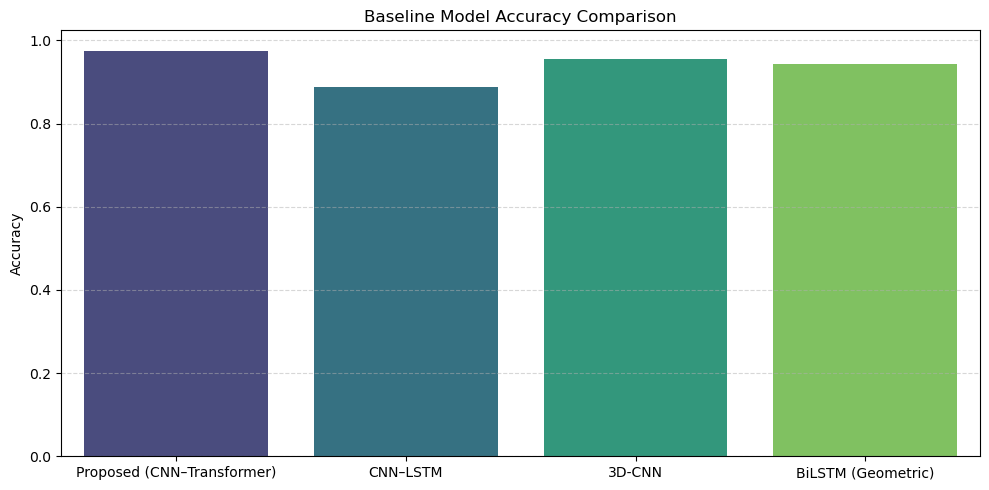

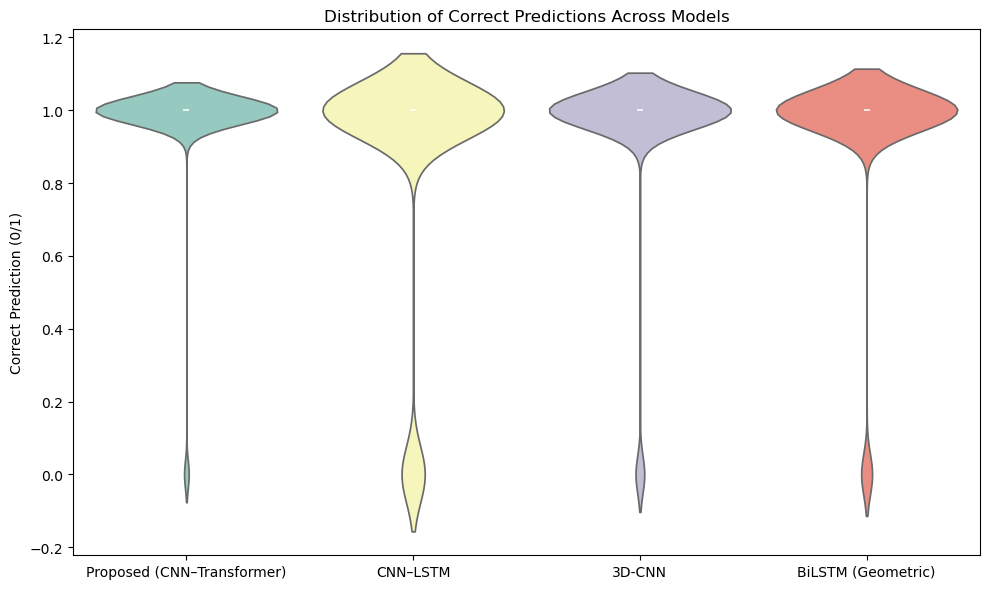

In [48]:
import numpy as np
from scipy.stats import friedmanchisquare
from statsmodels.stats.contingency_tables import mcnemar
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# 1) DEFINE MODELS (ONLY EXISTING ONES)
# ============================================================

models = [
    "transformer",   # Proposed
    "cnn_lstm",      # CNN–LSTM
    "3dcnn",         # 3D-CNN
    "bilstm"         # BiLSTM Geometric
]

model_names = [
    "Proposed (CNN–Transformer)",
    "CNN–LSTM",
    "3D-CNN",
    "BiLSTM (Geometric)"
]

# ============================================================
# 2) SANITY CHECK
# ============================================================

y_true = np.array(all_labels["transformer"])

for m in models:
    preds = np.array(all_preds[m])
    labels = np.array(all_labels[m])
    assert len(preds) == len(y_true)
    assert np.all(labels == y_true)

print("✅ All predictions aligned at video-level")
print("Number of test samples:", len(y_true))

# ============================================================
# 3) BUILD PERFORMANCE MATRIX (Correct / Incorrect)
# ============================================================

perf = []

for m in models:
    preds = np.array(all_preds[m])
    perf.append((preds == y_true).astype(int))

perf = np.array(perf)  # shape: (num_models, num_samples)

print("Performance matrix shape:", perf.shape)

# ============================================================
# 4) FRIEDMAN TEST (GLOBAL COMPARISON)
# ============================================================

stat, p = friedmanchisquare(*perf)

print("\n==============================")
print("📌 Friedman Test (Global)")
print("==============================")
print(f"Statistic = {stat:.4f}")
print(f"P-value   = {p:.6f}")

if p < 0.05:
    print("🔍 Statistically significant differences exist between models.")
else:
    print("ℹ No statistically significant difference detected.")

# ============================================================
# 5) PAIRWISE MCNEMAR TESTS
# ============================================================

print("\n==============================")
print("📌 Pairwise McNemar Tests")
print("==============================")

def mcnemar_test(pred_a, pred_b, labels):
    a = np.array(pred_a)
    b = np.array(pred_b)
    y = np.array(labels)

    b_count = np.sum((a == y) & (b != y))
    c_count = np.sum((a != y) & (b == y))

    table = [[0, b_count],
             [c_count, 0]]

    result = mcnemar(table, exact=True)
    return result.pvalue, b_count, c_count

for i in range(len(models)):
    for j in range(i + 1, len(models)):
        p_val, b, c = mcnemar_test(
            all_preds[models[i]],
            all_preds[models[j]],
            y_true
        )

        print(
            f"{model_names[i]:25s} vs {model_names[j]:25s} "
            f"→ p = {p_val:.6f}  (b={b}, c={c})"
        )

# ============================================================
# 6) ACCURACY BAR PLOT
# ============================================================

accuracies = [np.mean(perf[i]) for i in range(len(models))]

plt.figure(figsize=(10, 5))
sns.barplot(x=model_names, y=accuracies, palette="viridis")
plt.ylabel("Accuracy")
plt.title("Baseline Model Accuracy Comparison")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# ============================================================
# 7) VIOLIN PLOT (DISTRIBUTION OF CORRECT PREDICTIONS)
# ============================================================

plt.figure(figsize=(10, 6))
sns.violinplot(data=perf.T, palette="Set3")
plt.xticks(ticks=range(len(models)), labels=model_names)
plt.ylabel("Correct Prediction (0/1)")
plt.title("Distribution of Correct Predictions Across Models")
plt.tight_layout()
plt.show()


In [47]:
import numpy as np
import pandas as pd
from statsmodels.stats.multitest import multipletests

# ============================================================
# MANUAL HOCHBERG IMPLEMENTATION
# ============================================================

def hochberg_correction(pvals):
    """
    Manual implementation of Hochberg step-up procedure
    """
    pvals = np.array(pvals)
    m = len(pvals)

    order = np.argsort(pvals)[::-1]  # descending
    sorted_p = pvals[order]

    adjusted = np.zeros(m)
    for i in range(m):
        adjusted[i] = min((i + 1) * sorted_p[i], 1.0)

    # enforce monotonicity
    for i in range(m - 2, -1, -1):
        adjusted[i] = min(adjusted[i], adjusted[i + 1])

    # restore original order
    p_adj = np.empty(m)
    p_adj[order] = adjusted
    return p_adj


# ============================================================
# PAIRWISE p-values (من McNemar)
# ============================================================

pairs = []
p_values = []

models = ["transformer", "cnn_lstm", "3dcnn", "bilstm"]
names = [
    "Proposed (CNN–Transformer)",
    "CNN–LSTM",
    "3D-CNN",
    "BiLSTM (Geometric)"
]

y_true = np.array(all_labels["transformer"])

from statsmodels.stats.contingency_tables import mcnemar

def mcnemar_p(pred1, pred2, y):
    b = np.sum((pred1 == y) & (pred2 != y))
    c = np.sum((pred1 != y) & (pred2 == y))
    table = [[0, b], [c, 0]]
    return mcnemar(table, exact=True).pvalue

for i in range(len(models)):
    for j in range(i + 1, len(models)):
        p = mcnemar_p(
            np.array(all_preds[models[i]]),
            np.array(all_preds[models[j]]),
            y_true
        )
        pairs.append(f"{names[i]} vs {names[j]}")
        p_values.append(p)

p_values = np.array(p_values)

# ============================================================
# HOLM & HOCHBERG
# ============================================================

_, p_holm, _, _ = multipletests(p_values, method="holm")
p_hochberg = hochberg_correction(p_values)

# ============================================================
# FINAL TABLE (LIKE THE BOOK IMAGE)
# ============================================================

results_df = pd.DataFrame({
    "Comparison": pairs,
    "Unadjusted p": p_values,
    "p (Holm)": p_holm,
    "p (Hochberg)": p_hochberg
})

print("\n📊 Adjusted p-values Table:")
print(results_df)

# Save
results_df.to_csv("statistical_comparison_holm_hochberg.csv", index=False)
results_df.to_latex("statistical_comparison_holm_hochberg.tex", index=False)

print("\n📁 Saved successfully")



📊 Adjusted p-values Table:
                                         Comparison  Unadjusted p  \
0            Proposed (CNN–Transformer) vs CNN–LSTM  3.636120e-19   
1              Proposed (CNN–Transformer) vs 3D-CNN  3.201544e-03   
2  Proposed (CNN–Transformer) vs BiLSTM (Geometric)  1.266112e-04   
3                                CNN–LSTM vs 3D-CNN  6.748136e-13   
4                    CNN–LSTM vs BiLSTM (Geometric)  6.327895e-07   
5                      3D-CNN vs BiLSTM (Geometric)  2.298644e-01   

       p (Holm)  p (Hochberg)  
0  2.181672e-18  2.181672e-18  
1  6.403088e-03  2.181672e-18  
2  3.798335e-04  2.181672e-18  
3  3.374068e-12  2.181672e-18  
4  2.531158e-06  2.181672e-18  
5  2.298644e-01  2.181672e-18  

📁 Saved successfully


In [50]:
import numpy as np
import pandas as pd
from statsmodels.stats.multitest import multipletests

# ============================================================
# CORRECTED HOCHBERG IMPLEMENTATION
# ============================================================

def hochberg_correction(pvals):
    """
    Correct implementation of Hochberg step-up procedure.
    Follows the original algorithm: sort p-values in ascending order,
    then adjust from largest to smallest.
    """
    pvals = np.array(pvals)
    m = len(pvals)
    
    # Sort p-values in ascending order (not descending!)
    sorted_indices = np.argsort(pvals)
    sorted_p = pvals[sorted_indices]
    
    # Initialize adjusted p-values
    adjusted = np.empty(m)
    
    # Start from the largest p-value (last in sorted list)
    adjusted[m - 1] = sorted_p[m - 1]
    
    # Step down: p_adj[i] = min( (m - i) * p[i], p_adj[i + 1] )
    for i in range(m - 2, -1, -1):
        adjusted[i] = min((m - i) * sorted_p[i], adjusted[i + 1])
    
    # Restore original order
    p_adj = np.empty(m)
    p_adj[sorted_indices] = adjusted
    return p_adj


# ============================================================
# PAIRWISE p-values (من McNemar)
# ============================================================

pairs = []
p_values = []

models = ["transformer", "cnn_lstm", "3dcnn", "bilstm"]
names = [
    "Proposed (CNN–Transformer)",
    "CNN–LSTM",
    "3D-CNN",
    "BiLSTM (Geometric)"
]

y_true = np.array(all_labels["transformer"])

from statsmodels.stats.contingency_tables import mcnemar

def mcnemar_p(pred1, pred2, y):
    b = np.sum((pred1 == y) & (pred2 != y))
    c = np.sum((pred1 != y) & (pred2 == y))
    table = [[0, b], [c, 0]]
    return mcnemar(table, exact=True).pvalue

for i in range(len(models)):
    for j in range(i + 1, len(models)):
        p = mcnemar_p(
            np.array(all_preds[models[i]]),
            np.array(all_preds[models[j]]),
            y_true
        )
        pairs.append(f"{names[i]} vs {names[j]}")
        p_values.append(p)

p_values = np.array(p_values)

# ============================================================
# HOLM & HOCHBERG
# ============================================================

_, p_holm, _, _ = multipletests(p_values, method="holm")
p_hochberg = hochberg_correction(p_values)  # Now using the corrected function

# ============================================================
# FINAL TABLE (LIKE THE BOOK IMAGE)
# ============================================================

results_df = pd.DataFrame({
    "Comparison": pairs,
    "Unadjusted p": p_values,
    "p (Holm)": p_holm,
    "p (Hochberg)": p_hochberg
})

print("\n📊 Adjusted p-values Table:")
print(results_df)

# Save
results_df.to_csv("statistical_comparison_holm_hochberg.csv", index=False)
results_df.to_latex("statistical_comparison_holm_hochberg.tex", index=False)

print("\n📁 Saved successfully")


📊 Adjusted p-values Table:
                                         Comparison  Unadjusted p  \
0            Proposed (CNN–Transformer) vs CNN–LSTM  3.636120e-19   
1              Proposed (CNN–Transformer) vs 3D-CNN  3.201544e-03   
2  Proposed (CNN–Transformer) vs BiLSTM (Geometric)  1.266112e-04   
3                                CNN–LSTM vs 3D-CNN  6.748136e-13   
4                    CNN–LSTM vs BiLSTM (Geometric)  6.327895e-07   
5                      3D-CNN vs BiLSTM (Geometric)  2.298644e-01   

       p (Holm)  p (Hochberg)  
0  2.181672e-18  2.181672e-18  
1  6.403088e-03  6.403088e-03  
2  3.798335e-04  3.798335e-04  
3  3.374068e-12  3.374068e-12  
4  2.531158e-06  2.531158e-06  
5  2.298644e-01  2.298644e-01  

📁 Saved successfully


In [14]:
import json
import pandas as pd
import numpy as np
import os

# ===============================
# Base directory (بدون مسافة!)
# ===============================
base_dir = "/home/jovyan/final /experiments"

paths = {
    "BiLSTM (Geometric)": f"{base_dir}/results_bilstm_geometric_final.json",
    "3D-CNN": f"{base_dir}/results_CNN_single_frame.json",
    "CNN–LSTM": f"{base_dir}/cnn_lstm_results.json",
    "Proposed (CNN–Transformer)": f"{base_dir}/results_cnn_transformer_encrypted.json",
}

# ===============================
# Robust metric extractor
# ===============================
def extract_metrics(data):
    acc = macro_f1 = weighted_f1 = np.nan

    # Accuracy
    if "test_accuracy" in data:
        acc = data["test_accuracy"]
    elif "accuracy" in data:
        acc = data["accuracy"]

    # F1 scores
    if "classification_report" in data:
        cr = data["classification_report"]
        macro_f1 = cr.get("macro avg", {}).get("f1-score", np.nan)
        weighted_f1 = cr.get("weighted avg", {}).get("f1-score", np.nan)

    elif "report" in data:
        rp = data["report"]
        macro_f1 = rp.get("macro avg", {}).get("f1-score", np.nan)
        weighted_f1 = rp.get("weighted avg", {}).get("f1-score", np.nan)

    else:
        macro_f1 = data.get("macro_f1", np.nan)
        weighted_f1 = data.get("weighted_f1", np.nan)

    return acc, macro_f1, weighted_f1


# ===============================
# Load and build table
# ===============================
rows = []

for model, path in paths.items():
    assert os.path.exists(path), f"❌ File not found: {path}"

    with open(path, "r") as f:
        data = json.load(f)

    acc, mf1, wf1 = extract_metrics(data)

    rows.append({
        "Model": model,
        "Accuracy": acc,
        "Macro_F1": mf1,
        "Weighted_F1": wf1
    })

df = pd.DataFrame(rows)
df


,Model,Accuracy,Macro_F1,Weighted_F1
0,BiLSTM (Geometric),0.940585,0.911709,0.941811
1,3D-CNN,0.954296,0.937576,0.955333
2,CNN–LSTM,0.886654,0.874452,0.896874
3,Proposed (CNN–Transformer),0.975320,0.960182,0.975598


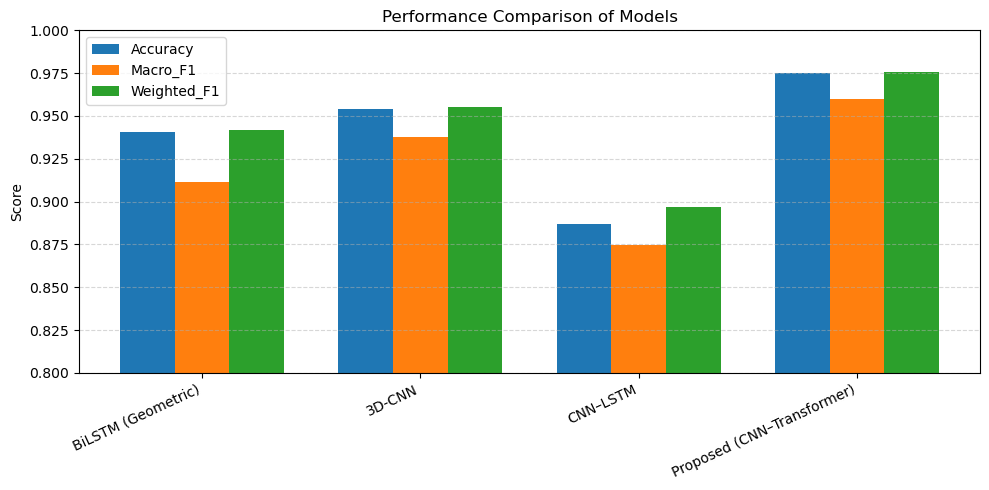

In [44]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["Accuracy", "Macro_F1", "Weighted_F1"]
x = np.arange(len(df["Model"]))
width = 0.25

plt.figure(figsize=(10,5))

for i, metric in enumerate(metrics):
    plt.bar(
        x + i*width,
        df[metric],
        width=width,
        label=metric
    )

plt.xticks(x + width, df["Model"], rotation=25, ha="right")
plt.ylabel("Score")
plt.ylim(0.8, 1.0)
plt.title("Performance Comparison of Models")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


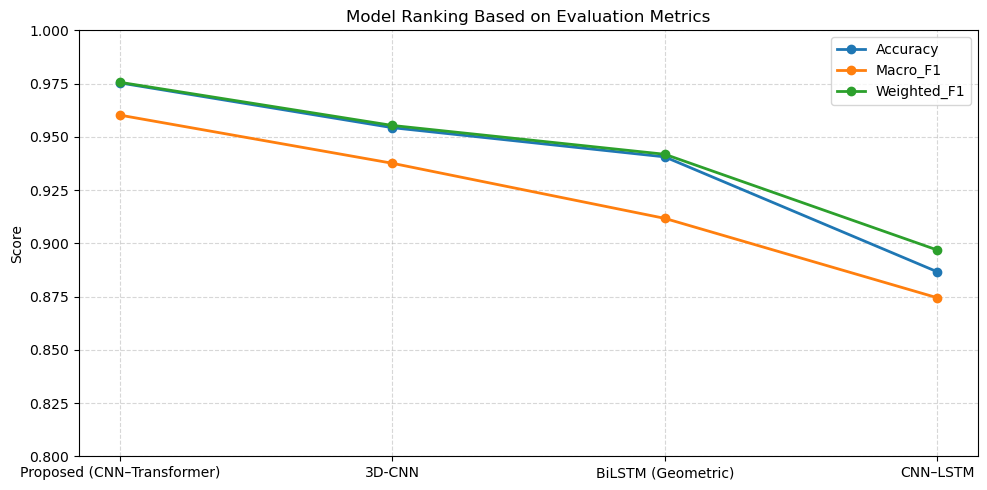

In [45]:
plt.figure(figsize=(10,5))

for metric in metrics:
    df_sorted = df.sort_values(metric, ascending=False)
    plt.plot(
        df_sorted["Model"],
        df_sorted[metric],
        marker="o",
        linewidth=2,
        label=metric
    )

plt.ylabel("Score")
plt.ylim(0.8, 1.0)
plt.title("Model Ranking Based on Evaluation Metrics")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


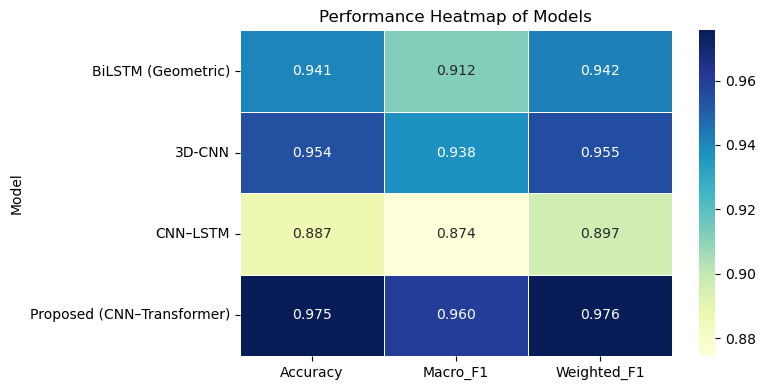

In [46]:
import seaborn as sns

plt.figure(figsize=(8,4))
sns.heatmap(
    df.set_index("Model"),
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Performance Heatmap of Models")
plt.tight_layout()
plt.show()
